# **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


# **Titanic Dataset Load**

In [3]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


#** Dataset basic overview**

## **Shape**

In [5]:
df.shape

(891, 15)

##**Columns**

In [6]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

# **First 5 rows**

In [7]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## **Last 5 rows**

In [8]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


# INFO

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


# Observation:-
The dataset contains numerical and categorical features. The info() method helps identify data types and missing values in each column.

# **Statistical Analysis**

In [10]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Observation:
The describe() function provides statistical information about numerical variables such as age, fare, sibsp and parch. The fare column shows a large difference between minimum and maximum values, indicating possible variation and potential outliers.

# **Value Counts**

## **SURVIVAL**

In [11]:
df["survived"].value_counts()

,count
survived,
0,549
1,342


## **GENDER**

In [12]:
df["sex"].value_counts()

,count
sex,
male,577
female,314


## **PASSENGER CLASS**

In [13]:
df["class"].value_counts()

,count
class,
Third,491
First,216
Second,184


#Observation:
The value_counts() results show the distribution of passengers across survival status, gender and passenger class.

# **Missing Values**

In [14]:
df.isnull().sum()
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

print(missing_values)

age            177
embarked         2
deck           688
embark_town      2
dtype: int64


#Observation:
The dataset contains missing values in some columns, particularly age, deck and embarked-related fields. Missing values need to be handled before performing certain analyses.

# **Handle Missing Values**

In [17]:
df["age"] = df["age"].fillna(df["age"].median())

df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


# **Survival Distribution**

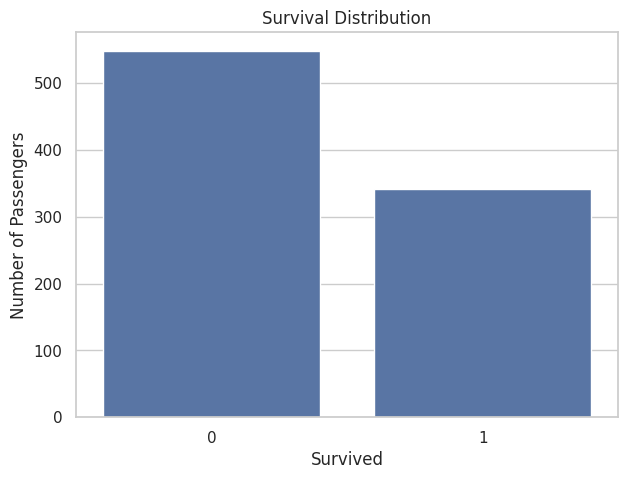

In [18]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="survived")

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

#Observation:
The number of passengers who did not survive was higher than the number of passengers who survived.

# **Gender vs Survival**

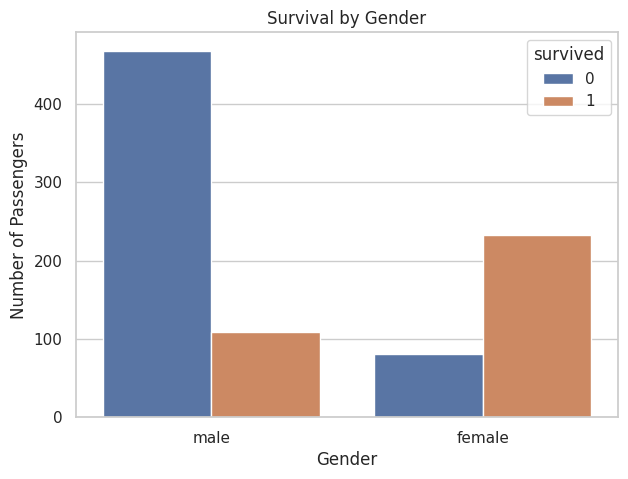

In [19]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="sex", hue="survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

# Observation:
Female passengers had a higher survival rate compared with male passengers.

# **Passenger Class vs Survival**

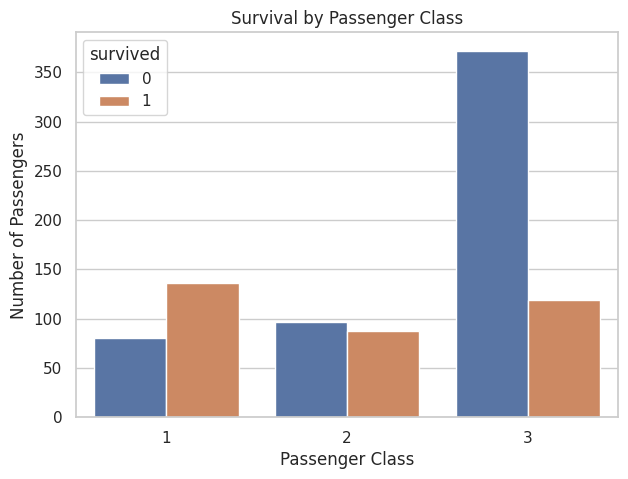

In [20]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="pclass", hue="survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

# Observation:
Passengers belonging to higher passenger classes generally had better survival outcomes than passengers in lower classes.

# **Histogram**

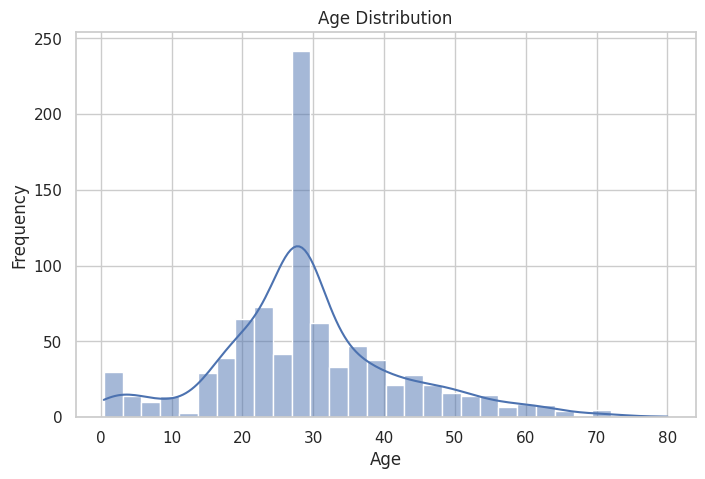

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="age", bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

# Observation:
The age distribution shows that most passengers were young and middle-aged adults, while relatively fewer passengers were elderly.

# **Fare Histogram**

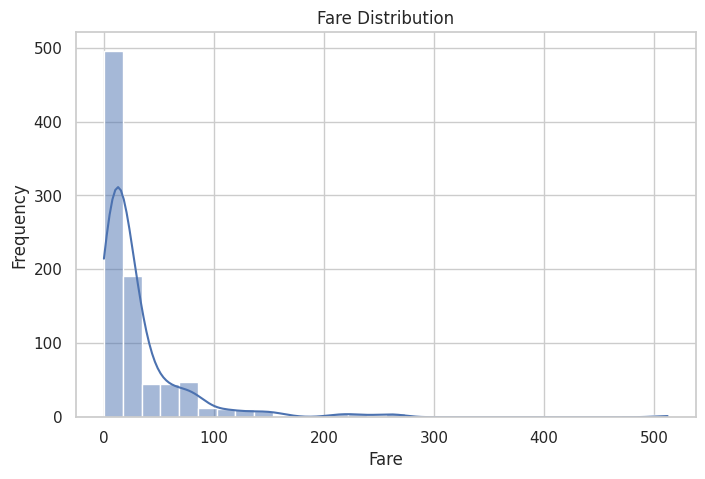

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="fare", bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

# Observation:
Most passengers paid relatively low fares, while a small number of passengers paid considerably higher fares.

# **Boxplot**

## **Age:**

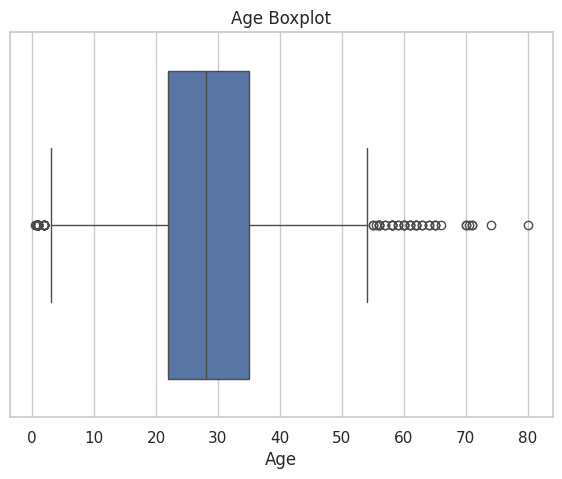

In [23]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x="age")

plt.title("Age Boxplot")
plt.xlabel("Age")

plt.show()

## **Fare:**

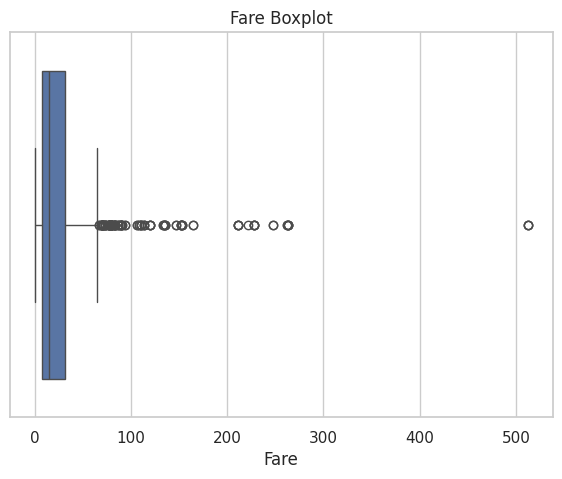

In [24]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x="fare")

plt.title("Fare Boxplot")
plt.xlabel("Fare")

plt.show()

# Observation:
The fare boxplot indicates the presence of several high-value observations that can be considered potential outliers.

# **Scatterplot**

## **Age vs Fare:**

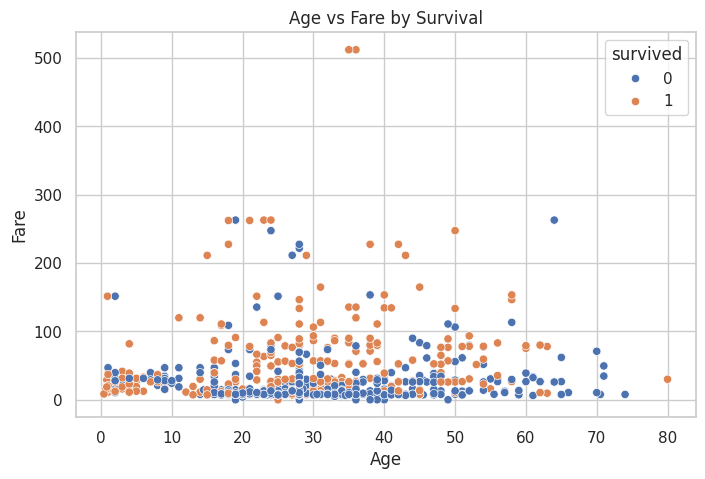

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived"
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

# Observation:
There is no strong linear relationship between age and fare. However, passengers paying higher fares appear across different age groups.

# **Pairplot**

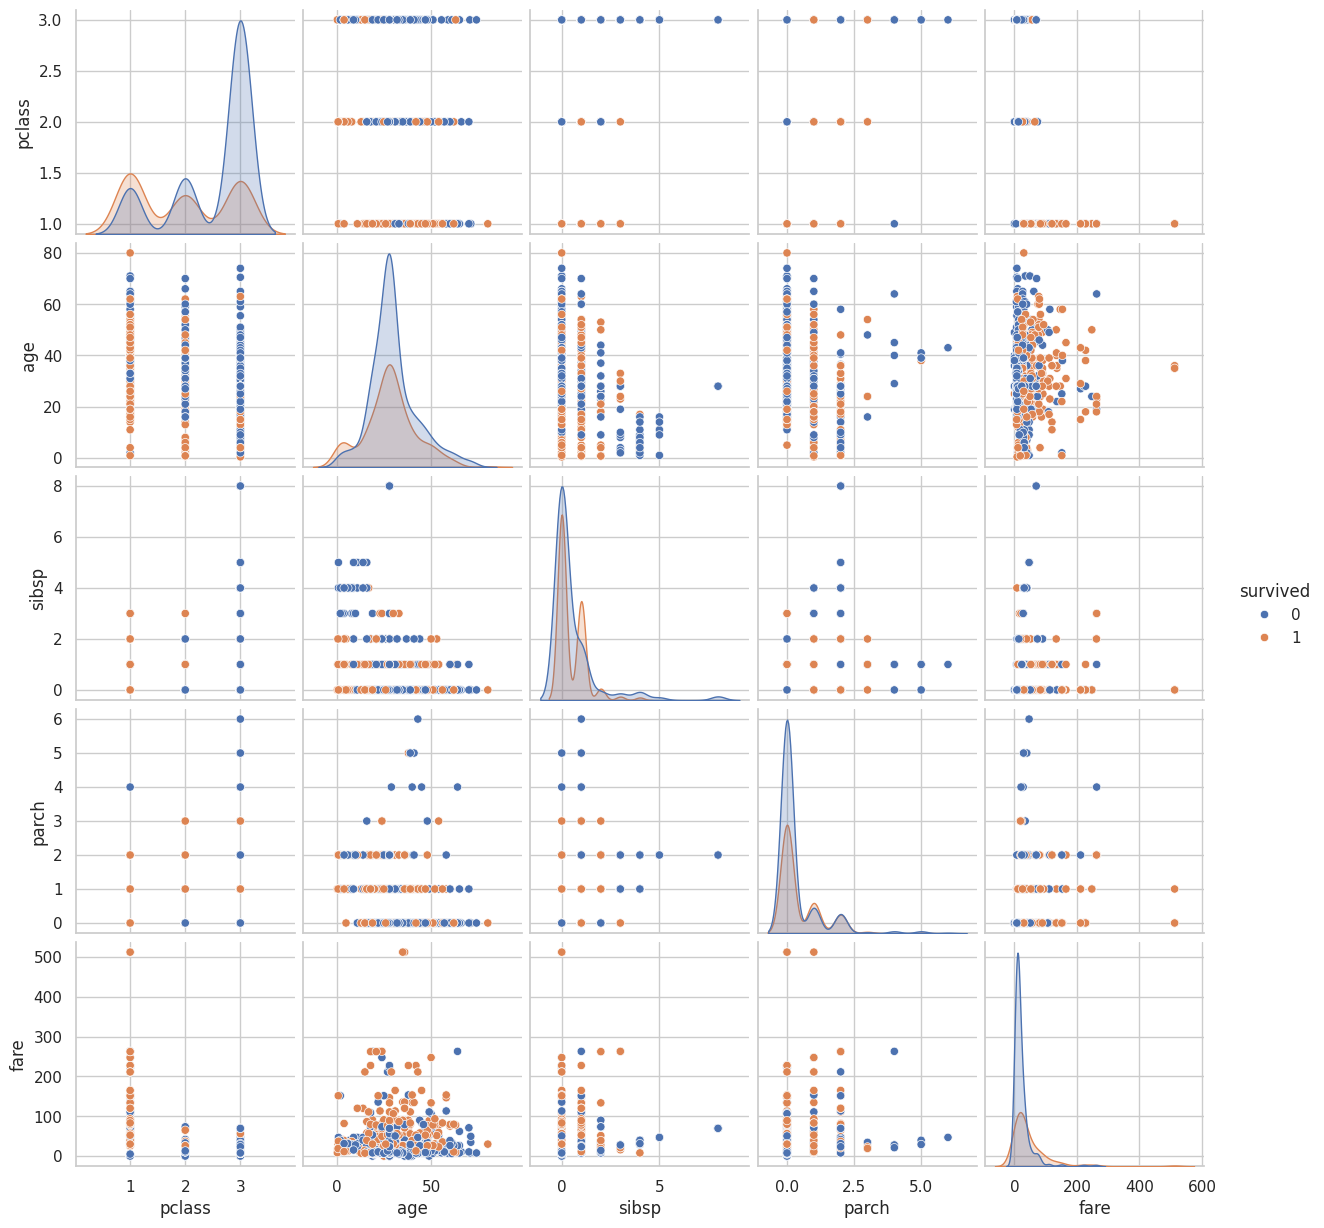

In [26]:
pairplot_data = df[
    ["survived", "pclass", "age", "sibsp", "parch", "fare"]
].copy()

sns.pairplot(
    pairplot_data,
    hue="survived"
)

plt.show()

# Observation:
The pairplot provides an overall view of relationships among numerical variables. Survival appears to vary with passenger class and fare, while some numerical variables show limited direct relationships.

# **Correlation Heatmap**

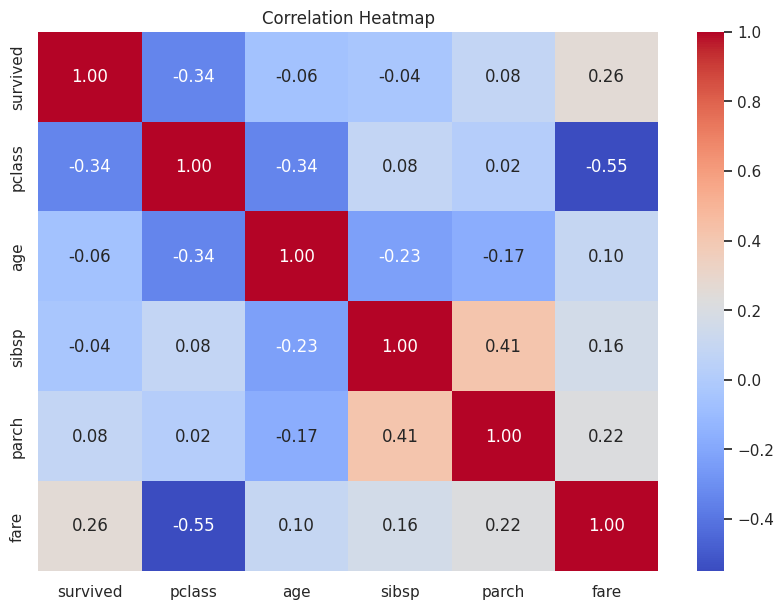

In [27]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Observation:
The heatmap shows the correlation between numerical variables. Passenger class and fare show an inverse relationship, while survival has a relationship with passenger class and fare.

# **Survival Rate by Gender**

In [28]:
survival_by_gender = df.groupby("sex")["survived"].mean()

print(survival_by_gender)

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


In [29]:
survival_by_gender = (
    df.groupby("sex")["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print(survival_by_gender)

sex
female    74.20
male      18.89
Name: survived, dtype: float64


# **Survival Rate by Class**

In [30]:
survival_by_class = (
    df.groupby("pclass")["survived"]
    .mean()
    .mul(100)
    .round(2)
)

print(survival_by_class)

pclass
1    62.96
2    47.28
3    24.24
Name: survived, dtype: float64


# Observation:
Survival rate differs significantly across passenger classes, with passengers in higher classes generally having better survival outcomes.

# **Age Group Analysis**

In [31]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)

df.groupby("age_group", observed=True)["survived"].mean()

,survived
age_group,
Child,0.579710
Teenager,0.428571
Young Adult,0.353271
Adult,0.400000
Senior,0.227273


In [32]:
(
    df.groupby("age_group", observed=True)["survived"]
    .mean()
    .mul(100)
    .round(2)
)

,survived
age_group,
Child,57.97
Teenager,42.86
Young Adult,35.33
Adult,40.00
Senior,22.73


# **Outlier Analysis**

In [33]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["fare"] < lower_bound) |
    (df["fare"] > upper_bound)
]

print("Number of Fare Outliers:", len(outliers))

Number of Fare Outliers: 116


# Observation:
The IQR method identifies several high fare values as potential outliers. These observations may represent passengers who paid significantly higher fares than most passengers.

#**Final Findings**

## Key Findings

1. The Titanic dataset contains both numerical and categorical variables.

2. Missing values were identified and handled for important analysis columns.

3. The overall number of passengers who did not survive was higher than those who survived.

4. Female passengers had a substantially better survival outcome than male passengers.

5. Passenger class was strongly associated with survival, with higher-class passengers generally having better survival outcomes.

6. Fare distribution was highly skewed, with several high-value observations acting as potential outliers.

7. Age and fare do not show a strong direct linear relationship.

8. The correlation heatmap shows relationships among numerical variables such as passenger class, fare, age and survival.

9. Pairplot analysis helps visualize relationships between numerical variables and survival.

10. Overall, gender, passenger class and fare were important factors associated with survival outcomes.